In [2]:
import pandas as pd

portfolio = pd.read_csv("portfolio.csv")
profile = pd.read_csv("profile.csv")
transcript = pd.read_csv("transcript.csv")

print(portfolio.head())
print(profile.head())
print(transcript.head())

   Unnamed: 0  reward                              channels  difficulty  \
0           0      10         ['email', 'mobile', 'social']          10   
1           1      10  ['web', 'email', 'mobile', 'social']          10   
2           2       0            ['web', 'email', 'mobile']           0   
3           3       5            ['web', 'email', 'mobile']           5   
4           4       5                      ['web', 'email']          20   

   duration     offer_type                                id  
0         7           bogo  ae264e3637204a6fb9bb56bc8210ddfd  
1         5           bogo  4d5c57ea9a6940dd891ad53e9dbe8da0  
2         4  informational  3f207df678b143eea3cee63160fa8bed  
3         7           bogo  9b98b8c7a33c4b65b9aebfe6a799e6d9  
4        10       discount  0b1e1539f2cc45b7b9fa7c272da2e1d7  
   Unnamed: 0 gender  age                                id  became_member_on  \
0           0    NaN  118  68be06ca386d4c31939f3a4f0e3dd783          20170212   
1        

In [3]:
# Flag and check how many "fake" profiles exist
fake_profiles = profile[profile['age'] == 118]
print(f"Fake/missing profiles: {len(fake_profiles)} out of {len(profile)}")

# Drop them for now (we can revisit later if needed)
profile_clean = profile[profile['age'] != 118].copy()

Fake/missing profiles: 2175 out of 17000


In [4]:
import ast

# Convert the string that looks like a dict into an actual dict
transcript['value_dict'] = transcript['value'].apply(ast.literal_eval)

# Pull out the useful fields
transcript['offer_id'] = transcript['value_dict'].apply(lambda x: x.get('offer id') or x.get('offer_id'))
transcript['amount'] = transcript['value_dict'].apply(lambda x: x.get('amount'))
transcript['reward_received'] = transcript['value_dict'].apply(lambda x: x.get('reward'))

print(transcript['event'].value_counts())
print(transcript.head())

ValueError: malformed node or string: nan

In [5]:
import ast

def safe_eval(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except (ValueError, SyntaxError):
            return {}
    return {}

transcript['value_dict'] = transcript['value'].apply(safe_eval)

transcript['offer_id'] = transcript['value_dict'].apply(lambda x: x.get('offer id') or x.get('offer_id'))
transcript['amount'] = transcript['value_dict'].apply(lambda x: x.get('amount'))
transcript['reward_received'] = transcript['value_dict'].apply(lambda x: x.get('reward'))

print(transcript['event'].value_counts())
print(transcript.head())

event
transaction        110513
offer received      76277
offer viewed        50373
offer completed     26775
Name: count, dtype: int64
   Unnamed: 0                            person           event  \
0           0  78afa995795e4d85b5d9ceeca43f5fef  offer received   
1           1  a03223e636434f42ac4c3df47e8bac43  offer received   
2           2  e2127556f4f64592b11af22de27a7932  offer received   
3           3  8ec6ce2a7e7949b1bf142def7d0e0586  offer received   
4           4  68617ca6246f4fbc85e91a2a49552598  offer received   

                                              value  time  \
0  {'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'}   0.0   
1  {'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'}   0.0   
2  {'offer id': '2906b810c7d4411798c6938adc9daaa5'}   0.0   
3  {'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'}   0.0   
4  {'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'}   0.0   

                                         value_dict  \
0  {'offer id': '9b98b8c7a33c4b65b9aebf

In [6]:
# Total spend per person (from transaction events only)
spend_per_person = transcript[transcript['event'] == 'transaction'].groupby('person')['amount'].sum().reset_index()
spend_per_person.columns = ['person', 'total_spend']

# Did each person complete at least one offer?
completers = transcript[transcript['event'] == 'offer completed']['person'].unique()
spend_per_person['completed_offer'] = spend_per_person['person'].isin(completers)

print(spend_per_person['completed_offer'].value_counts())
print(spend_per_person.groupby('completed_offer')['total_spend'].mean())

completed_offer
True     11838
False     4518
Name: count, dtype: int64
completed_offer
False     18.622470
True     111.556933
Name: total_spend, dtype: float64


In [7]:
# For each person, check the order of events per offer they received
viewed = set(transcript[transcript['event'] == 'offer viewed']['person'] + transcript[transcript['event'] == 'offer viewed']['offer_id'].astype(str))
completed = transcript[transcript['event'] == 'offer completed'].copy()
completed['person_offer'] = completed['person'] + completed['offer_id'].astype(str)

completed['was_viewed'] = completed['person_offer'].isin(viewed)
print(completed['was_viewed'].value_counts())

was_viewed
True     22658
False     4117
Name: count, dtype: int64


In [8]:
# Get the set of "person_offer" combos for each category
blind_completers = set(completed[completed['was_viewed'] == False]['person_offer'])
real_completers = set(completed[completed['was_viewed'] == True]['person'])
blind_people = set(completed[completed['was_viewed'] == False]['person'])

spend_per_person['real_completer'] = spend_per_person['person'].isin(real_completers)
spend_per_person['blind_completer'] = spend_per_person['person'].isin(blind_people) & ~spend_per_person['person'].isin(real_completers)

def group_label(row):
    if row['real_completer']:
        return 'viewed_then_completed'
    elif row['blind_completer']:
        return 'blind_completion_only'
    else:
        return 'no_real_completion'

spend_per_person['group'] = spend_per_person.apply(group_label, axis=1)

print(spend_per_person['group'].value_counts())
print(spend_per_person.groupby('group')['total_spend'].mean())

group
viewed_then_completed    11143
no_real_completion        4518
blind_completion_only      695
Name: count, dtype: int64
group
blind_completion_only     60.837194
no_real_completion        18.622470
viewed_then_completed    114.720373
Name: total_spend, dtype: float64


In [9]:
# Get the time each person first viewed an offer
first_view = transcript[transcript['event'] == 'offer viewed'].groupby('person')['time'].min().reset_index()
first_view.columns = ['person', 'first_view_time']

# Get all transactions with their timestamp
transactions = transcript[transcript['event'] == 'transaction'][['person', 'time', 'amount']]

# Merge to know each transaction's timing relative to first offer view
merged = transactions.merge(first_view, on='person', how='inner')

merged['period'] = merged.apply(
    lambda row: 'before' if row['time'] < row['first_view_time'] else 'after', axis=1
)

before_after = merged.groupby(['person', 'period'])['amount'].sum().unstack(fill_value=0)
print(before_after.mean())

period
after     78.381414
before     8.379643
dtype: float64


In [10]:
# Get how many days each period actually covers, per person
first_view_days = first_view.copy()
first_view_days['first_view_time'] = first_view_days['first_view_time']

# Total observation window is time 0 to max time in dataset
max_time = transcript['time'].max()

merged_days = first_view.copy()
merged_days['before_days'] = merged_days['first_view_time'] / 24  # time is in hours
merged_days['after_days'] = (max_time - merged_days['first_view_time']) / 24

# Merge spend numbers back in
spend_summary = before_after.reset_index().merge(merged_days, on='person')

# Spend PER DAY, not total spend
spend_summary['before_per_day'] = spend_summary['before'] / spend_summary['before_days'].replace(0, 0.5)
spend_summary['after_per_day'] = spend_summary['after'] / spend_summary['after_days'].replace(0, 0.5)

print(spend_summary[['before_per_day', 'after_per_day']].mean())

before_per_day    1.316338
after_per_day     4.303888
dtype: float64


In [11]:
# Total reward paid out (from completed offers)
total_reward_paid = transcript[transcript['event'] == 'offer completed']['reward_received'].sum()

# Total extra spend estimate: (after_per_day - before_per_day) * average days in "after" period * number of people
avg_after_days = spend_summary['after_days'].mean()
n_people = len(spend_summary)
extra_spend_per_day = spend_summary['after_per_day'].mean() - spend_summary['before_per_day'].mean()

estimated_extra_revenue = extra_spend_per_day * avg_after_days * n_people

print(f"Total reward paid out: ${total_reward_paid:,.2f}")
print(f"Estimated extra revenue generated: ${estimated_extra_revenue:,.2f}")
print(f"Return ratio (revenue per $1 of reward): {estimated_extra_revenue / total_reward_paid:.2f}")

Total reward paid out: $132,093.00
Estimated extra revenue generated: $905,064.11
Return ratio (revenue per $1 of reward): 6.85


Part 2

In [12]:
# Merge everything into one clean table
profile_clean['became_member_on'] = pd.to_datetime(profile_clean['became_member_on'], format='%Y%m%d')
profile_clean['membership_days'] = (pd.Timestamp('2018-12-31') - profile_clean['became_member_on']).dt.days

# Treatment: did they view before completing? (from your earlier group split)
spend_per_person['treatment'] = (spend_per_person['group'] == 'viewed_then_completed').astype(int)

# Merge with spend_summary (has after_per_day) and profile_clean (has confounders)
causal_df = spend_per_person.merge(spend_summary[['person', 'after_per_day']], on='person', how='inner')
causal_df = causal_df.merge(profile_clean[['id', 'age', 'income', 'membership_days']], left_on='person', right_on='id', how='inner')

causal_df = causal_df[['person', 'treatment', 'after_per_day', 'age', 'income', 'membership_days']].dropna()
print(causal_df.shape)
print(causal_df.head())

(14050, 6)
                             person  treatment  after_per_day  age   income  \
0  0009655768c64bdeb2e877511632db8f          1       4.225846   33  72000.0   
1  0011e0d4e6b944f998e987f904e8c1e5          1       1.977917   40  57000.0   
2  0020c2b971eb4e9188eac86d93036a77          1       6.291789   59  90000.0   
3  0020ccbbb6d84e358d3414a3ff76cffd          1       6.955942   24  60000.0   
4  003d66b6608740288d6cc97a6903f4f0          1       1.527033   26  73000.0   

   membership_days  
0              619  
1              356  
2             1032  
3              780  
4              558  


In [14]:
!pip install dowhy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.9/245.9 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 109.6 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
  Attempting uninstall: cvxpy
    Found existing installation: cvxpy 1.6.7
    Uninstalling cvxpy-1.6.7:
      Successfully uninstalled cvxpy-1.6.7


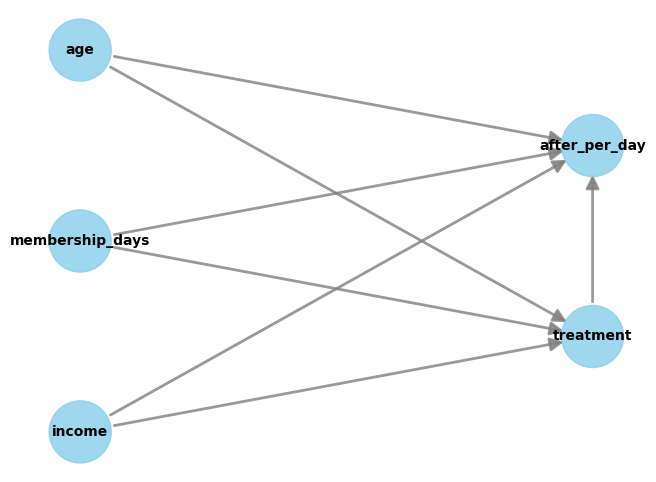

In [15]:
from dowhy import CausalModel

model = CausalModel(
    data=causal_df,
    treatment='treatment',
    outcome='after_per_day',
    common_causes=['age', 'income', 'membership_days']
)

model.view_model()

In [16]:
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                   
────────────(E[after_per_day|income,age,membership_days])
d[treatment]                                             
Estimand assumption 1, Unconfoundedness: If U→{treatment} and U→after_per_day then P(after_per_day|treatment,income,age,membership_days,U) = P(after_per_day|treatment,income,age,membership_days)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
     d                                                   
────────────(E[after_per_day|income,membership_days,age])
d[treatment]                                             
Estimand assumption 1, Unconfoundedness: If U→{treatment} and U→after_per_day then P(after_per_day|treatment,income,membership_days,age,U) = P

In [17]:
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression"
)
print(estimate)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                   
────────────(E[after_per_day|income,age,membership_days])
d[treatment]                                             
Estimand assumption 1, Unconfoundedness: If U→{treatment} and U→after_per_day then P(after_per_day|treatment,income,age,membership_days,U) = P(after_per_day|treatment,income,age,membership_days)

## Realized estimand
b: after_per_day~treatment+income+age+membership_days
Target units: ate

## Estimate
Mean value: 3.5345901585322603



In [18]:
# Test 1: add a random/fake confounder - if the estimate barely changes, that's reassuring
refute1 = model.refute_estimate(identified_estimand, estimate, method_name="random_common_cause")
print(refute1)

# Test 2: replace treatment with a placebo (fake/random treatment) - estimate should collapse toward 0
refute2 = model.refute_estimate(identified_estimand, estimate, method_name="placebo_treatment_refuter")
print(refute2)

Refute: Add a random common cause
Estimated effect:3.5345901585322603
New effect:3.534612856543846
p value:0.98

Refute: Use a Placebo Treatment
Estimated effect:3.5345901585322603
New effect:-0.0021974356961333365
p value:1.0

